# Data Acquisition
**Goals:**
1. Pull OpenStreetMap network (GraphML file format)
2. Pull grocery stores (GeoDataframe -> GeoJSON)
3. Pull Census tracts, boundaries (GeoJSON)
4. Pull Census demographics (JSON -> Dataframe)
5. Pull transit stops (CSV)
6. Make visualizations
7. Save all outputs to `data/raw/` and `data/processed/`

In [61]:
import osmnx as ox
import geopandas as gpd
import pandas as pd
import folium
import os

CITY = "Kingstowne"
STATE = "Virginia"
STATE_FIPS = "51"
COUNTY_FIPS = "059"
PROJECTION = "epsg:4326"

PLACE = f"{CITY}, {STATE}"
RAW_DIR = "../data/raw"
PROCESSED_DIR = "../data/processed"
print(f"Working on {PLACE}...")

Working on Kingstowne, Virginia...


## 1. Network graph data
https://osmnx.readthedocs.io/en/stable/user-reference.html#osmnx.graph.graph_from_place

In [2]:
# creates a street network for walking routes in Kingstowne
walk_graph = ox.graph_from_place(PLACE, network_type="walk")
print(f"Nodes: {len(walk_graph.nodes)}")
print(f"Edges: {len(walk_graph.edges)}")
ox.save_graphml(walk_graph, f"{RAW_DIR}/{CITY.lower()}_walk_network.graphml")

Nodes: 2653
Edges: 7400


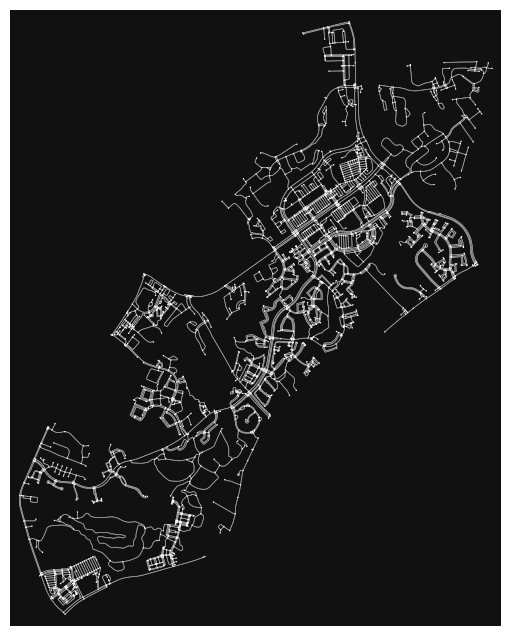

In [3]:
fig, ax = ox.plot_graph(
    walk_graph, 
    node_size=1, 
    edge_linewidth=0.5, 
)

## 2. Points of interest
https://osmnx.readthedocs.io/en/stable/user-reference.html#osmnx.features.features_from_place

In [59]:
poi_tags = {
    "grocery" : {"shop" : ["supermarket", "grocery"]}
}

for category, tags in poi_tags.items():
    try:
        # downloads point features that are tagged as supermarkets or groceries
        grocery_gdf = ox.features_from_place(PLACE, tags)
        # keep everything that's not null
        grocery_gdf = grocery_gdf[grocery_gdf.geometry.notnull()].copy()
        grocery_gdf["category"] = category
        print(f"{category}: {len(grocery_gdf)} features")
    except Exception as e:
        print(e)

grocery: 4 features


In [62]:
grocery_gdf["geometry"] = grocery_gdf.geometry.apply(lambda geom: geom.centroid if geom.geom_type != "Point" else geom)
grocery_gdf = grocery_gdf[["geometry", "brand", "category"]]
grocery_gdf = gpd.GeoDataFrame(grocery_gdf, geometry="geometry", crs=PROJECTION) # epsg:4326 which is WGS 84
grocery_gdf.to_file(f"{RAW_DIR}/{CITY.lower()}_pois.geojson", driver="GeoJSON")
grocery_gdf

geometry    brand category
element id                                                      
node    4208133624  POINT (-77.13706 38.77271)    Giant  grocery
        7956135900  POINT (-77.13994 38.76798)     Aldi  grocery
        7956150256   POINT (-77.1414 38.77002)  Safeway  grocery
way     391755853   POINT (-77.16108 38.74257)  Wegmans  grocery

## 3. Census tracts and boundaries
- Using 2024 boundary shapefile to match the most recent American Community Survey (2020-2024)

In [63]:
tracts = gpd.read_file("../data/raw/tl_2024_51_tract/tl_2024_51_tract.shp")
tracts = gpd.GeoDataFrame(tracts, geometry="geometry", crs=PROJECTION) # keeps tracts as WGS84
print(f"Tracts pulled: {len(tracts)}")
print(f"CRS: {tracts.crs}")
print(tracts.head())
print(tracts.info())


Tracts pulled: 2198
CRS: epsg:4326
  STATEFP COUNTYFP TRACTCE        GEOID               GEOIDFQ     NAME  \
0      51      025  930302  51025930302  1400000US51025930302  9303.02   
1      51      025  930301  51025930301  1400000US51025930301  9303.01   
2      51      147  930302  51147930302  1400000US51147930302  9303.02   
3      51      147  930204  51147930204  1400000US51147930204  9302.04   
4      51      147  930101  51147930101  1400000US51147930101  9301.01   

               NAMELSAD  MTFCC FUNCSTAT      ALAND   AWATER     INTPTLAT  \
0  Census Tract 9303.02  G5020        S  342689262  2060807  +36.6455249   
1  Census Tract 9303.01  G5020        S  250104609  3377443  +36.6303680   
2  Census Tract 9303.02  G5020        S  239112486  2887009  +37.2064829   
3  Census Tract 9302.04  G5020        S   25244099   366455  +37.3049747   
4  Census Tract 9301.01  G5020        S   12382648    94738  +37.2850335   

       INTPTLON                                           geome

## 4. Demographics at the tract level
- Median income (https://api.census.gov/data/2024/acs/acs5/groups/B19013.html)
- No vehicle households (https://api.census.gov/data/2024/acs/acs5/groups/B08201.html)
- Population (https://api.census.gov/data/2024/acs/acs5/groups/B01003.html)

In [ ]:
import requests

CENSUS_API_KEY = os.environ.get("CENSUS_API_KEY")

ACS_VARS = {
    "B19013_001E": "median_income",
    "B08201_002E": "no_vehicle_households",
    "B01003_001E": "population",
}

variables = ",".join(ACS_VARS.keys())
url = (
    f"https://api.census.gov/data/2024/acs/acs5"
    f"?get=NAME,{variables}&for=tract:*&in=state:{STATE_FIPS}&in=county:{COUNTY_FIPS}"
    f"&key={CENSUS_API_KEY}"
)
response = requests.get(url)
data = response.json()
acs_df = pd.DataFrame(data[1:], columns=data[0])
for col in ACS_VARS.keys():
    acs_df[col] = pd.to_numeric(acs_df[col], errors="coerce")
acs_df = acs_df.rename(columns=ACS_VARS)
acs_df["GEOID"] = acs_df["state"] + acs_df["county"] + acs_df["tract"]
print(f"Tract rows: {len(acs_df)}")


Tract rows: 274


In [34]:
acs_df.head()
acs_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 274 entries, 0 to 273
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   NAME                   274 non-null    str  
 1   median_income          274 non-null    int64
 2   no_vehicle_households  274 non-null    int64
 3   population             274 non-null    int64
 4   state                  274 non-null    str  
 5   county                 274 non-null    str  
 6   tract                  274 non-null    str  
 7   GEOID                  274 non-null    str  
dtypes: int64(3), str(5)
memory usage: 17.3 KB


In [32]:
acs_df["NAME"] = acs_df["NAME"].apply(lambda name: name.split(";")[0][13:])
acs_df.head()

,NAME,median_income,no_vehicle_households,population,state,county,tract,GEOID
0,4151,205938,16,3604,51,059,415100,51059415100
1,4152,107634,167,2966,51,059,415200,51059415200
2,4153,121795,313,4145,51,059,415300,51059415300
3,4154.01,85114,269,6688,51,059,415401,51059415401
4,4154.02,185481,15,2438,51,059,415402,51059415402


In [35]:
acs_df = acs_df[acs_df["population"] > 0]

## 3B. Filter tracts to the study area and merge with demographics

In [ ]:
city_boundary = ox.geocode_to_gdf(PLACE)
city_boundary = city_boundary.to_crs(PROJECTION)

In [37]:
center = city_boundary.geometry.iloc[0].centroid
map = folium.Map(location=[center.y, center.x], zoom_start=12, tiles="cartodbpositron")
folium.GeoJson(
    city_boundary,
    style_function=lambda x: {"fillColor": "#ffffff00", "color": "#666666", "weight": 1},
).add_to(map)
map

In [41]:
tracts_in_city = gpd.sjoin(tracts, city_boundary, predicate="overlaps", how="inner")
tracts_in_city = tracts_in_city.drop(columns=[c for c in tracts_in_city.columns if c.endswith("_right")])
print(f"Tracts within {CITY}: {len(tracts_in_city)}")

Tracts within Kingstowne: 6


In [42]:
tracts_merged = tracts_in_city.merge(acs_df, on="GEOID", how="left")
print(f"Merged tracts: {len(tracts_merged)}, missing demographic data: {tracts_merged['median_income'].isna().sum()}")
tracts_merged[["GEOID", "median_income", "no_vehicle_households", "population"]]

Merged tracts: 6, missing demographic data: 0


,GEOID,median_income,no_vehicle_households,population
0,51059421103,145865,29,6355
1,51059422403,236012,0,3186
2,51059422402,151451,54,4984
3,51059421102,150929,130,3611
4,51059422301,156107,46,2642
5,51059422302,136176,58,6254


In [43]:
tracts_merged.to_file(f"{PROCESSED_DIR}/{CITY.lower()}_tracts_demographics.geojson", driver="GeoJSON")

## 4. Transit data
- Fairfax Connector bus stops (https://mobilitydatabase.org/feeds?q=Fairfax+Connector)

In [51]:
stops_df = pd.read_csv("../data/raw/connector_gtfs/stops.txt")

print(f"Stops loaded: {len(stops_df)}")
stops_df.head()

Stops loaded: 3119


,stop_id,stop_code,stop_name,stop_desc,stop_lat,stop_lon,zone_id,stop_url,location_type,parent_station,stop_timezone,wheelchair_boarding
0,2,1004,RICHMOND HWY @ BACKLICK RD,NaN,38.708492,-77.160581,NaN,NaN,NaN,NaN,NaN,0
1,3,1005,RICHMOND HWY @ SOUTHGATE DR,NaN,38.773520,-77.081300,NaN,NaN,NaN,NaN,NaN,1
2,4,1007,RICHMOND HWY @ COLLARD ST,NaN,38.766970,-77.083650,NaN,NaN,NaN,NaN,NaN,0
3,5,1008,RICHMOND HWY @ FORDSON RD,NaN,38.749140,-77.083220,NaN,NaN,NaN,NaN,NaN,0
4,6,1009,RICHMOND HWY @ LOCKHEED BLVD,NaN,38.758500,-77.084000,NaN,NaN,NaN,NaN,NaN,0


In [ ]:
stops_gdf = gpd.GeoDataFrame(
    stops_df,
    geometry=gpd.points_from_xy(stops_df["stop_lon"], stops_df["stop_lat"]),
    crs=PROJECTION,  # GTFS lat/lon is WGS84
)

In [73]:
stops_gdf = stops_gdf[["stop_id", "stop_name", "wheelchair_boarding", "geometry"]]
stops_gdf.head()


,stop_id,stop_name,wheelchair_boarding,geometry
0,2,RICHMOND HWY @ BACKLICK RD,0,POINT (-77.16058 38.70849)
1,3,RICHMOND HWY @ SOUTHGATE DR,1,POINT (-77.0813 38.77352)
2,4,RICHMOND HWY @ COLLARD ST,0,POINT (-77.08365 38.76697)
3,5,RICHMOND HWY @ FORDSON RD,0,POINT (-77.08322 38.74914)
4,6,RICHMOND HWY @ LOCKHEED BLVD,0,POINT (-77.084 38.7585)


In [76]:
print(f"Stops: {stops_gdf.crs}")
print(f"City: {city_boundary.crs}")

Stops: epsg:4326
City: epsg:4326


In [81]:
city_boundary

,geometry,bbox_west,bbox_south,bbox_east,bbox_north,place_id,osm_type,osm_id,lat,lon,class,type,place_rank,importance,addresstype,name,display_name
0,"POLYGON ((-77.16753 38.74869, -77.16752 38.748...",-77.167532,38.740042,-77.121969,38.784071,347794220,relation,18347702,38.762132,-77.144409,boundary,census,25,0.378584,census,Kingstowne,"Kingstowne, Fairfax County, Virginia, United S..."


In [85]:
stops_in_city = gpd.sjoin(stops_gdf, tracts_in_city, predicate="within", how="inner")
stops_in_city = stops_in_city.drop(columns=[c for c in stops_in_city.columns if c.endswith("_right")])

In [86]:
print(f"Original: {len(stops_gdf)}")
print(f"After join: {len(stops_in_city)}")

Original: 3119
After join: 118


In [88]:
stops_in_city

,stop_id,stop_name,wheelchair_boarding,geometry,STATEFP,COUNTYFP,TRACTCE,GEOID,GEOIDFQ,NAME,...,osm_id,lat,lon,class,type,place_rank,importance,addresstype,name,display_name
37,40,SUMMER RIDGE RD @ WORSLEY WAY,0,POINT (-77.13728 38.76034),51,059,422402,51059422402,1400000US51059422402,4224.02,...,18347702,38.762132,-77.144409,boundary,census,25,0.378584,census,Kingstowne,"Kingstowne, Fairfax County, Virginia, United S..."
40,44,KINGSTOWNE BLVD @ SIR VICEROY DR,0,POINT (-77.13541 38.77148),51,059,422302,51059422302,1400000US51059422302,4223.02,...,18347702,38.762132,-77.144409,boundary,census,25,0.378584,census,Kingstowne,"Kingstowne, Fairfax County, Virginia, United S..."
44,50,KINGSTOWNE BLVD @ KINGSTOWNE CTR,0,POINT (-77.13469 38.77222),51,059,422302,51059422302,1400000US51059422302,4223.02,...,18347702,38.762132,-77.144409,boundary,census,25,0.378584,census,Kingstowne,"Kingstowne, Fairfax County, Virginia, United S..."
48,54,FRANCONIA RD @ EDISON HIGH SCHOOL,0,POINT (-77.13302 38.78397),51,059,422301,51059422301,1400000US51059422301,4223.01,...,18347702,38.762132,-77.144409,boundary,census,25,0.378584,census,Kingstowne,"Kingstowne, Fairfax County, Virginia, United S..."
124,153,BEULAH ST @ CHARLES ARRINGTON DR,0,POINT (-77.15512 38.76687),51,059,422302,51059422302,1400000US51059422302,4223.02,...,18347702,38.762132,-77.144409,boundary,census,25,0.378584,census,Kingstowne,"Kingstowne, Fairfax County, Virginia, United S..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2935,3762,CINDER BED RD TEST,0,POINT (-77.18445 38.7337),51,059,421103,51059421103,1400000US51059421103,4211.03,...,18347702,38.762132,-77.144409,boundary,census,25,0.378584,census,Kingstowne,"Kingstowne, Fairfax County, Virginia, United S..."
2942,3775,BEULAH ST @ MORNING VIEW LN,0,POINT (-77.16651 38.7514),51,059,421103,51059421103,1400000US51059421103,4211.03,...,18347702,38.762132,-77.144409,boundary,census,25,0.378584,census,Kingstowne,"Kingstowne, Fairfax County, Virginia, United S..."
2943,3776,BEULAH ST @ MORNING VIEW LA,0,POINT (-77.16653 38.7513),51,059,421103,51059421103,1400000US51059421103,4211.03,...,18347702,38.762132,-77.144409,boundary,census,25,0.378584,census,Kingstowne,"Kingstowne, Fairfax County, Virginia, United S..."
3030,3871,KINGSTOWNE BLVD @ KINGSTOWNE TOWN CENTRE,0,POINT (-77.13703 38.77089),51,059,422302,51059422302,1400000US51059422302,4223.02,...,18347702,38.762132,-77.144409,boundary,census,25,0.378584,census,Kingstowne,"Kingstowne, Fairfax County, Virginia, United S..."


In [89]:
stops_gdf.to_file(f"{RAW_DIR}/{CITY.lower()}_stops.geojson", driver="GeoJSON")

## 5. Visualizations

In [91]:
center = city_boundary.geometry.iloc[0].centroid
map = folium.Map(location=[center.y, center.x], zoom_start=12, tiles="cartodbpositron")

folium.GeoJson(
    city_boundary.to_crs(PROJECTION),
    style_function=lambda x: {"fillColor": "#ffffff00", "color": "#D0920E", "weight": 2},
).add_to(map)

folium.GeoJson(
    tracts_merged.to_crs(PROJECTION),
    style_function=lambda x: {"fillColor": "#ffffff00", "color": "#666666", "weight": 1},
).add_to(map)

colors = {"grocery": "green"}
for _, row in grocery_gdf.iterrows():
    folium.CircleMarker(
        location=[row.geometry.y, row.geometry.x],
        radius=3,
        color=colors.get(row["category"], "gray"),
        fill=True,
        popup=row.get("name", row["category"]),
    ).add_to(map)


for _, row in stops_in_city.iterrows():
    folium.CircleMarker(
        location=[row.geometry.y, row.geometry.x],
        radius=1,
        color="blue",
        fill=True,
        popup=row.get("stop_name"),
    ).add_to(map)

map
